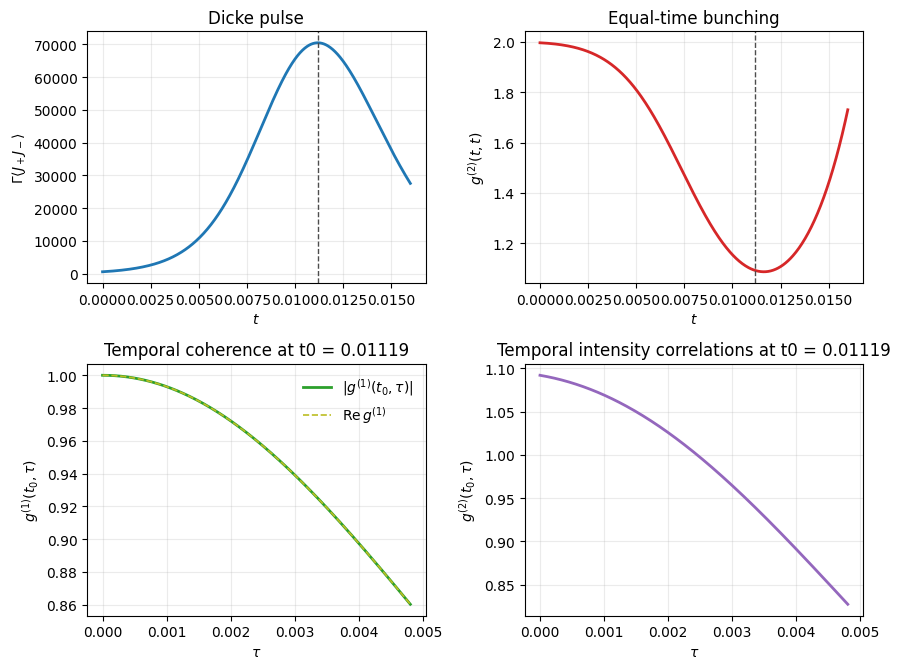

(S = 300, Gamma = 1.0, t = [0.0, 3.204874576761596e-5, 6.409749153523192e-5, 9.614623730284787e-5, 0.00012819498307046383, 0.00016024372883807978, 0.00019229247460569575, 0.0002243412203733117, 0.00025638996614092766, 0.00028843871190854364  …  0.015703885426131818, 0.015735934171899436, 0.01576798291766705, 0.015800031663434667, 0.01583208040920228, 0.0158641291549699, 0.015896177900737513, 0.01592822664650513, 0.015960275392272745, 0.015992324138040363], rho_t = Operator{SpinBasis{300//1, Int64}, SpinBasis{300//1, Int64}, Matrix{ComplexF64}}[Operator(dim=601x601)
  basis: Spin(300)
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0

In [22]:
#!/usr/bin/env julia

using QuantumOptics
using PyPlot
using Printf

"""
    run_dicke_correlations(; kwargs...)

Compute equal-time and two-time correlations for Dicke superradiance in the
fully symmetric spin-S manifold.

The collective emitter is represented by `SpinBasis(S)` and evolves under

    d rho / dt = Gamma * D[J_-] rho

with `J_- = sigmam(basis)`. The default initial state is the fully inverted
Dicke state `|S, m=S>`.

Returned quantities:

* `G1_t(t) = <J_+(t) J_-(t)>`
* `g1_t(t,t) = 1` wherever `G1_t` is nonzero, kept explicit for completeness
* `G2_t(t) = <J_+(t) J_+(t) J_-(t) J_-(t)>`
* `g2_t(t,t) = G2_t(t) / G1_t(t)^2`
* `G1_tau(t0,tau) = <J_+(t0+tau) J_-(t0)>`
* `g1_tau(t0,tau) = G1_tau / sqrt(n(t0) n(t0+tau))`
* `G2_tau(t0,tau) = <J_+(t0) J_+(t0+tau) J_-(t0+tau) J_-(t0)>`
* `g2_tau(t0,tau) = G2_tau / (n(t0) n(t0+tau))`

Here `n(t) = <J_+(t)J_-(t)>`. `Gamma*n(t)` is the emitted intensity.
"""
function run_dicke_correlations(;
    S = 10,
    Gamma = 1.0,
    nt = 500,
    tmax = nothing,
    temporal_nt = 300,
    temporal_taumax = nothing,
    reference = :peak,
    reltol = 1e-8,
    abstol = 1e-10,
    make_plot = true,
    save_plot = true,
    outfile = nothing,
)
    b = SpinBasis(S)
    psi0 = spinup(b)
    rho0 = dm(psi0)

    Jm = sigmam(b)
    Jp = sigmap(b)
    n_op = Jp * Jm
    pair_op = Jp * Jp * Jm * Jm
    H = SparseOperator(b)
    jumps = [Jm]
    rates = [Gamma]

    n_atoms = 2 * Float64(S)
    if tmax === nothing
        tmax = 10.0 * log(max(n_atoms, 2.0)) / (Gamma * max(n_atoms, 1.0))
    end
    ts = collect(range(0.0, tmax, length = nt))

    tout, rhos = timeevolution.master(
        ts, rho0, H, jumps;
        rates = rates,
        reltol = reltol,
        abstol = abstol,
    )

    G1_t = real_expect.(Ref(n_op), rhos)
    G2_t = real_expect.(Ref(pair_op), rhos)
    intensity_t = Gamma .* G1_t
    g1_t = map(x -> x > 0 ? 1.0 : NaN, G1_t)
    g2_t = safe_divide(G2_t, G1_t .^ 2)

    ref_index = choose_reference_index(reference, tout, intensity_t)
    rho_ref = rhos[ref_index]
    t0 = tout[ref_index]
    if temporal_taumax === nothing
        temporal_taumax = max(tout[end] - t0, tmax / 4)
    end
    taus = collect(range(0.0, temporal_taumax, length = temporal_nt))

    temporal = temporal_correlations(
        taus, rho_ref, H, jumps, rates, Jm, Jp, n_op;
        reltol = reltol,
        abstol = abstol,
    )

    result = (
        S = S,
        Gamma = Gamma,
        t = tout,
        rho_t = rhos,
        G1_t = G1_t,
        g1_t = g1_t,
        G2_t = G2_t,
        g2_t = g2_t,
        intensity_t = intensity_t,
        reference_index = ref_index,
        t0 = t0,
        tau = taus,
        temporal = temporal,
    )

    if make_plot
        if outfile === nothing
            outfile = joinpath(@__DIR__, "dicke_superradiance_correlations_S$(label_string(S)).pdf")
        end
        plot_dicke_correlations(result; save_plot = save_plot, outfile = outfile)
    end

    return result
end

function temporal_correlations(
    taus, rho0, H, jumps, rates, Jm, Jp, n_op;
    reltol = 1e-8,
    abstol = 1e-10,
)
    n0 = real(expect(n_op, rho0))

    G1_tau = timecorrelations.correlation(
        taus, rho0, H, jumps, Jp, Jm;
        rates = rates,
        reltol = reltol,
        abstol = abstol,
    )

    _, n_tau = timeevolution.master(
        taus, rho0, H, jumps;
        rates = rates,
        fout = (_, rho) -> real(expect(n_op, rho)),
        reltol = reltol,
        abstol = abstol,
    )

    rho_cond = Jm * rho0 * Jp
    _, G2_tau = timeevolution.master(
        taus, rho_cond, H, jumps;
        rates = rates,
        fout = (_, rho) -> real(expect(n_op, rho)),
        reltol = reltol,
        abstol = abstol,
    )

    n_tau = real.(n_tau)
    G2_tau = real.(G2_tau)
    g1_tau = safe_divide(G1_tau, sqrt.(n0 .* n_tau))
    g2_tau = safe_divide(G2_tau, n0 .* n_tau)

    return (
        n0 = n0,
        n_tau = n_tau,
        G1_tau = G1_tau,
        g1_tau = g1_tau,
        G2_tau = G2_tau,
        g2_tau = g2_tau,
    )
end

real_expect(op, rho) = real(expect(op, rho))

function safe_divide(num, den; eps = 1e-14)
    return [abs(d) > eps ? n / d : NaN for (n, d) in zip(num, den)]
end

function choose_reference_index(reference, t, intensity)
    if reference == :peak
        return argmax(intensity)
    elseif reference isa Integer
        return clamp(reference, firstindex(t), lastindex(t))
    elseif reference isa Real
        _, idx = findmin(abs.(t .- reference))
        return idx
    else
        error("reference must be :peak, an integer time index, or a real time")
    end
end

label_string(x) = replace(string(x), "//" => "over", "/" => "over")

function plot_dicke_correlations(result; save_plot = true, outfile = "dicke_superradiance_correlations.pdf")
    t = result.t
    tau = result.tau
    temporal = result.temporal

    fig, ax = subplots(2, 2, figsize = (9.0, 6.8))

    ax[1, 1].plot(t, result.intensity_t, color = "tab:blue", lw = 2)
    ax[1, 1].axvline(result.t0, color = "0.3", ls = "--", lw = 1)
    ax[1, 1].set_xlabel("\$t\$")
    ax[1, 1].set_ylabel("\$\\Gamma \\langle J_+J_-\\rangle\$")
    ax[1, 1].set_title("Dicke pulse")

    ax[1, 2].plot(t, result.g2_t, color = "tab:red", lw = 2)
    ax[1, 2].axvline(result.t0, color = "0.3", ls = "--", lw = 1)
    ax[1, 2].set_xlabel("\$t\$")
    ax[1, 2].set_ylabel("\$g^{(2)}(t,t)\$")
    ax[1, 2].set_title("Equal-time bunching")

    ax[2, 1].plot(tau, abs.(temporal.g1_tau), color = "tab:green", lw = 2, label = "\$|g^{(1)}(t_0,\\tau)|\$")
    ax[2, 1].plot(tau, real.(temporal.g1_tau), color = "tab:olive", lw = 1.2, ls = "--", label = "\$\\mathrm{Re}\\,g^{(1)}\$")
    ax[2, 1].set_xlabel("\$\\tau\$")
    ax[2, 1].set_ylabel("\$g^{(1)}(t_0,\\tau)\$")
    ax[2, 1].set_title(@sprintf("Temporal coherence at t0 = %.4g", result.t0))
    ax[2, 1].legend(frameon = false)

    ax[2, 2].plot(tau, temporal.g2_tau, color = "tab:purple", lw = 2)
    ax[2, 2].set_xlabel("\$\\tau\$")
    ax[2, 2].set_ylabel("\$g^{(2)}(t_0,\\tau)\$")
    ax[2, 2].set_title(@sprintf("Temporal intensity correlations at t0 = %.4g", result.t0))

    for a in ax
        a.grid(true, alpha = 0.25)
    end

    fig.tight_layout()

    if save_plot
        fig.savefig(outfile, bbox_inches = "tight")
        @info "Saved plot" outfile
    end

    return fig, ax
end

N = 600
result = run_dicke_correlations(;tmax = 1.5 * log(N) / N, S = N ÷ 2)

